In [1]:
# STEP 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# STEP 2: Install Required Libraries
!pip install scikit-image opencv-python

# STEP 3: Import Libraries
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import joblib
from google.colab import files

# STEP 4: Fog Removal Function using CLAHE
def remove_fog_clahe(gray_img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return clahe.apply(gray_img)

# STEP 5: Feature Extraction Function using HOG + Fog Removal
def extract_features_from_folder(folder, label):
    features = []
    labels = []
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)              # ✅ Convert to grayscale
            fog_removed = remove_fog_clahe(gray)                      # ✅ Fog removal using CLAHE
            resized = cv2.resize(fog_removed, (128, 128))             # ✅ Resize
            hog_feat = hog(resized, orientations=9, pixels_per_cell=(8, 8),
                           cells_per_block=(2, 2), visualize=False)
            features.append(hog_feat)
            labels.append(label)
    return features, labels

# STEP 6: Load Data
missile_path = "/content/drive/MyDrive/drdo_project/dataset/missile"
bird_path = "/content/drive/MyDrive/drdo_project/dataset/birds"

missile_features, missile_labels = extract_features_from_folder(missile_path, 1)
bird_features, bird_labels = extract_features_from_folder(bird_path, 0)

X = missile_features + bird_features
y = missile_labels + bird_labels

# STEP 7: Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# STEP 8: Train SVM Model
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

# STEP 9: Evaluate Model
y_pred = svm.predict(X_test)
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("✅ Classification Report:\n", classification_report(y_test, y_pred))

# STEP 10: Save Model
joblib.dump(svm, "svm_model.pkl")
files.download("svm_model.pkl")

# STEP 11: Predict Single Image with Fog Removal
def predict_image(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    fog_removed = remove_fog_clahe(gray)
    resized = cv2.resize(fog_removed, (128, 128))
    features = hog(resized, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
    prediction = svm.predict([features])[0]
    label = "Missile" if prediction == 1 else "Bird"
    print("🔍 Prediction:", label)
    return label

# ✅ Example:
# predict_image("/content/drive/MyDrive/sample_test.jpg")


Mounted at /content/drive
✅ Accuracy: 0.8931297709923665
✅ Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.65      0.71        79
           1       0.91      0.96      0.93       314

    accuracy                           0.89       393
   macro avg       0.85      0.80      0.82       393
weighted avg       0.89      0.89      0.89       393



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import cv2
import imutils
import datetime

gun_cascade = cv2.CascadeClassifier('cascade.xml')
camera = cv2.VideoCapture(0)
firstFrame = None
gun_exist = False
while True:
    ret, frame = camera.read()
    if frame is None:
        break
    frame = imutils.resize(frame, width=500)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gun = gun_cascade.detectMultiScale(gray, 1.3, 20, minSize=(100, 100))
    if len(gun) > 0:
        gun_exist = True
    for (x, y, w, h) in gun:
        frame = cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
        roi_gray = gray[y:y + h, x:x + w]
        roi_color = frame[y:y + h, x:x + w]
    if firstFrame is None:
        firstFrame = gray
        continue
    cv2.putText(frame, datetime.datetime.now().strftime("%A %d %B %Y %I:%M:%S %p"),
                (10, frame.shape[0] - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.35, (0, 0, 255), 1)
    if gun_exist:
        print("Guns detected")
        plt.imshow(frame)
        break
    else:
        cv2.imshow("Security Feed", frame)
    key = cv2.waitKey(1) & 0xFF
    if key == ord('q'):
        break

camera.release()
cv2.destroyAllWindows()

In [2]:
from google.colab import files

# Upload the trained SVM model (.pkl file)
print("Upload the trained svm_model.pkl file:")
uploaded_model = files.upload()


from google.colab import files
# Upload the test image you want to classify
print("\nUpload a test image (missile or bird):")
uploaded_image = files.upload()
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
import joblib
# Load the trained SVM model
model_filename = list(uploaded_model.keys())[0]
svm = joblib.load(model_filename)
def predict_image(img_path):
    # Read image
    image = cv2.imread(img_path)

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize to match training size
    resized = cv2.resize(gray, (128, 128))

    # Extract HOG features
    features = hog(resized, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), block_norm='L2-Hys')

    # Predict using SVM
    pred = svm.predict([features])[0]
    label = "Missile" if pred == 1 else "Bird"

    # Show result
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(f"Prediction: {label}")
    plt.axis('off')
    plt.show()

    return label
# Predict on uploaded image
image_filename = list(uploaded_image.keys())[0]
print("\nRunning prediction on:", image_filename)
result = predict_image(image_filename)
print("Prediction Result:", result)


Upload the trained svm_model.pkl file:


KeyboardInterrupt: 

✅ SVM model loaded successfully!
📤 Upload a test image (Missile or Bird):


Saving images.jpeg to images (1).jpeg

🔍 Running prediction on: images (1).jpeg


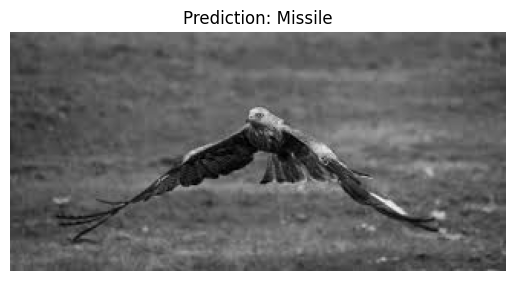

✅ Final Prediction: Missile


In [5]:
# STEP 1: Mount Google Drive

# STEP 2: Import Required Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
import joblib
import os
from google.colab import files

# STEP 3: Load the model from Drive path
model_path = "/content/svm_model.pkl"
svm = joblib.load(model_path)
print("✅ SVM model loaded successfully!")

# STEP 4: Upload the test image
print("📤 Upload a test image (Missile or Bird):")
uploaded_image = files.upload()

# STEP 5: Prediction Function
def predict_image(img_path):
    image = cv2.imread(img_path)

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply CLAHE for fog removal
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    fog_removed = clahe.apply(gray)

    # Resize image
    resized = cv2.resize(fog_removed, (128, 128))

    # HOG feature extraction
    features = hog(resized, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), block_norm='L2-Hys')

    # Prediction
    prediction = svm.predict([features])[0]
    label = "Missile" if prediction == 1 else "Bird"

    # Show image with label
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(f"Prediction: {label}")
    plt.axis('off')
    plt.show()

    return label

# STEP 6: Run prediction on uploaded image
image_filename = list(uploaded_image.keys())[0]
print("\n🔍 Running prediction on:", image_filename)
result = predict_image(image_filename)
print("✅ Final Prediction:", result)


✅ SVM model loaded successfully!
📤 Upload a test image (Missile or Bird):


Saving singleBirdinsky183_jpeg.rf.be9bece412f33326d7ba04e5fba65463.jpg to singleBirdinsky183_jpeg.rf.be9bece412f33326d7ba04e5fba65463.jpg

🔍 Running prediction on: singleBirdinsky183_jpeg.rf.be9bece412f33326d7ba04e5fba65463.jpg


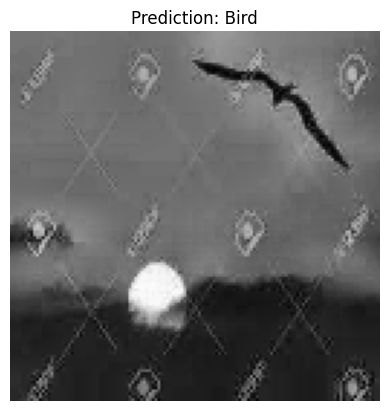

✅ Final Prediction: Bird


In [7]:
# STEP 2: Import Required Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
import joblib
import os
from google.colab import files

# STEP 3: Load the model from Drive path
model_path = "/content/svm_model.pkl"
svm = joblib.load(model_path)
print("✅ SVM model loaded successfully!")

# STEP 4: Upload the test image
print("📤 Upload a test image (Missile or Bird):")
uploaded_image = files.upload()

# STEP 5: Prediction Function
def predict_image(img_path):
    image = cv2.imread(img_path)

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply CLAHE for fog removal
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    fog_removed = clahe.apply(gray)

    # Resize for model
    resized = cv2.resize(fog_removed, (128, 128))

    # Extract HOG features
    features = hog(resized, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), block_norm='L2-Hys')

    # Predict using SVM
    prediction = svm.predict([features])[0]
    label = "Missile" if prediction == 1 else "Bird"

    # Show grayscale processed image
    plt.imshow(resized, cmap='gray')
    plt.title(f"Prediction: {label}")
    plt.axis('off')
    plt.show()

    return label

# STEP 6: Run prediction on uploaded image
image_filename = list(uploaded_image.keys())[0]
print("\n🔍 Running prediction on:", image_filename)
result = predict_image(image_filename)
print("✅ Final Prediction:", result)
